In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
#from plot_results import convert_signal, comparison_signals, comparison_freq, qtrans_plot, gwpy_to_pycbc, pycbc_to_gwpy
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['font.size'] = 14  # global font size
import sys
sys.path.append('/home/victor-glorieux/Internship_Victor_CBC_ET')
sys.path.append('/home/victor/Internship_Victor_CBC_ET')
import numpy as np
import pandas as pd
from plot_functions import plot_mnimisation, plot_correlation_2_params, plot_correlation_spinSz_spinAz

/home/victor/miniconda3/envs/pycbc_env/lib/python3.9/site-packages/pycbc/inference/models/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import iter_entry_points as _iter_entry_points


-973775.6777255697
Iterations totales :  40000
(200, 200)
Maximum log-likelihood ratio at:-615449.21956072186
mchirp = 29.13
q = 1.36


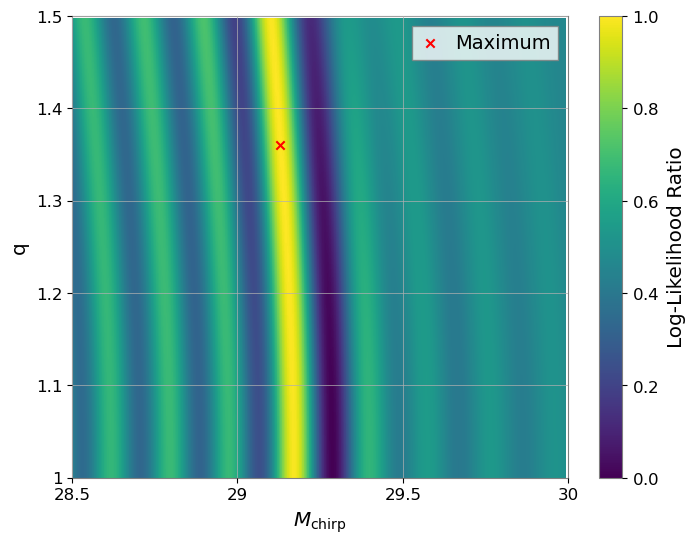

In [6]:
import generation_signal

sample_rate = 2048
fmin = 5.
cbc_params = {
            # Paramètres intrinsèques à la source
            'mass1': 38.6,
            'mass2': 29.3,
            'spin1x': 0., 'spin2x': 0.,  'spin1y': 0., 'spin2y': 0.,  'spin1z': 0, 'spin2z': 0,
            'eccentricity': 0,
            # Paramètres extrinsèques
            #'ra': 1.37, 'dec': -1.26, 'distance': 1000,
            'ra': 3*(np.pi/2), 'dec': -np.pi/4, 'distance': 1000,
            'polarization': 2.76, 'inclination': (3*np.pi)/4,
            'tc': 3.1 , 'coa_phase': 0}

cbc_params = {
              'mass1': 38.6,
              'mass2': 29.3,
              'spin1x': 0., 'spin2x': 0.,  'spin1y': 0., 'spin2y': 0.,  'spin1z': 0, 'spin2z': 0, 
              'eccentricity': 0,
              'ra': 1.37, 'dec': -1.26, 'distance': 500, 
              'polarization': 2.76, 'inclination': 0,
              'tc': 3.1 , 'coa_phase': 0.3,
              'approximant': 'IMRPhenomXPHM',
              'f_lower': 5
                }


model, log_noise_likelihood_from_SNR, signal = generation_signal.generation_signal_GW(cbc_params,sample_rate,
                                                                              fmin,noise=False,print_snr=False)

#bounds_x = {"minx" : 0, "maxx" : 2*np.pi} #ra
#xticks = {"values" : [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], "labels" : [r'0', r'$\pi$/2', r'$\pi$', r'3$\pi$/2', r'2$\pi$']} #ra
#bounds_y = {"miny" : -np.pi/2, "maxy" : np.pi/2} #dec
#yticks = {"values" : [-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2], "labels" : [r'- $\pi$/2', r'- $\pi$/4', r'0', r'$\pi$/4', r'$\pi$/2']} #dec
#bounds_y = {"miny" : 0, "maxy" : np.pi} #incl
#yticks = {"values" : [0, np.pi/4, np.pi/2, (3*np.pi)/4, np.pi], "labels" : [r'0', r'$\pi$/4', r'$\pi$/2', r'3$\pi$/4', r'$\pi$']} #incl
# bounds_x = {"minx" :30, "maxx" : 45} #mass1
# xticks = {"values" : [30, 33, 36, 39, 42, 45], "labels" : ['30','33', '36', '39', '42', '45']} #mass1
#bounds_y = {"miny" : 1, "maxy" : 5} #tc
#yticks = {"values" : [1, 2, 3, 4, 5, 6], "labels" : ['1', '2', '3', '4', '5', '6']} #tc
bounds_x = {"minx" :28.5, "maxx" : 30} #chirp
xticks = {"values" : [28.5, 29, 29.5, 30], "labels" : ['28.5','29', '29.5', '30']} #chirp
bounds_y = {"miny" : 1, "maxy" : 1.5} #q
yticks = {"values" : [1, 1.1, 1.2, 1.3, 1.4, 1.5], "labels" : ['1', '1.1','1.2', '1.3', '1.4', '1.5']} #q
#bounds_x = {"minx" : 0, "maxx" : 1} #spinz
#bounds_y = {"miny" : 0, "maxy" : 1} #spinz


#bounds_x = {"minx" : 1, "maxx" : 5000}
#bounds_y = {"miny" : 1, "maxy" : 5}
model.update(**cbc_params)
print(model.loglr)
bounds_color = None
#bounds_color = {"inf" : -2000, "sup" : model.loglr}
div = 200
plot_correlation_2_params(model,cbc_params,param_x_name='mchirp',param_y_name='q',range_x=1,range_y=1,ech_x=(bounds_x["maxx"] - bounds_x["minx"])/div,ech_y=(bounds_y["maxy"] - bounds_y["miny"])/div,
                          x_label=r'$M_\text{chirp}$',y_label=r'q',bounds_y=bounds_y,bounds_x=bounds_x,xticks=xticks,yticks=yticks, bounds_color=bounds_color)

In [ ]:
import generation_signal

sample_rate = 2048
fmin = 5.
cbc_params = {
            # Paramètres intrinsèques à la source
            'mass1': 38.6,
            'mass2': 29.3,
            'spin1x': 0., 'spin2x': 0.,  'spin1y': 0., 'spin2y': 0.,  'spin1z': 0.1, 'spin2z': 0.2,
            'eccentricity': 0,
            # Paramètres extrinsèques
            'ra': 1.37, 'dec': -1.26, 'distance': 1000,
            'polarization': 2.76, 'inclination': (3*np.pi)/4,
            'tc': 3.1 , 'coa_phase': 0}

model, log_noise_likelihood_from_SNR, signal = generation_signal.generation_signal_GW(cbc_params,sample_rate,
                                                                              fmin,noise=False,print_snr=False)

plot_correlation_spinSz_spinAz(model,cbc_params)